# ЛАБОРАТОРНА РОБОТА 8-9

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import animation

from scipy.optimize import differential_evolution
import pyswarms as ps

In [18]:
iterations = 100
popsize = 40

## Differential Evolution

In [ ]:
de_tol = 1e-8
de_mutation = 0.8
de_recombination = 0.9

def de(func, bounds):

    history = []

    def save_history(intermediate_result=None):

        best_point = intermediate_result.x
        x, y = best_point
        z = intermediate_result.fun
        history.append([x, y, z])

    result = differential_evolution(
        func=func,
        bounds=bounds,
        maxiter=iterations,
        popsize=popsize,
        tol=de_tol,
        mutation=de_mutation,
        recombination=de_recombination,
        callback=save_history,
        seed=42,
        polish=True
    )

    return result, history

## PSO

In [20]:
pso_options = {
    'c1': 1.49,
    'c2': 1.49,
    'w': 0.72
}


def objective_swarm(particles, func):

    values = []
    for particle in particles:
        values.append(func(particle))
    return np.array(values)


def pso(func, bounds):

    history = []
    dimensions = len(bounds)
    lower_bounds = np.array([b[0] for b in bounds])
    upper_bounds = np.array([b[1] for b in bounds])

    optimizer = ps.single.GlobalBestPSO(
        n_particles=popsize,
        dimensions=dimensions,
        options=pso_options,
        bounds=(lower_bounds, upper_bounds)
    )

    cost, pos = optimizer.optimize(
        objective_swarm,
        iters=iterations,
        func=func,
        verbose=False
    )

    for i in range(len(optimizer.cost_history)):

        best_point = optimizer.pos_history[i][0]
        x, y = best_point
        z = optimizer.cost_history[i]
        history.append([x, y, z])

    return cost, pos, history

## Функції без функціональних обмежень

In [21]:
def f_schaffer_1(v):
    x, y = v
    numerator = np.sin(x**2 - y**2)**2 - 0.5
    denominator = (1 + 0.001*(x**2 + y**2))**2
    return 0.5 + numerator/denominator

def f_ackley(v):
    x, y = v

    return (
        -20 * np.exp(-0.2 * np.sqrt(0.5 * (x**2 + y**2)))
        - np.exp(0.5 * (np.cos(2*np.pi*x) + np.cos(2*np.pi*y)))
        + np.e + 20
    )

def f_holder(v):
    x, y = v

    return -np.abs(
        np.sin(x)
        * np.cos(y)
        * np.exp(np.abs(1 - np.sqrt(x**2 + y**2) / np.pi))
    )

In [22]:
FUNCTIONS = {

    "schaffer1": {
        "func": f_schaffer_1,
        "bounds": [(-100, 100), (-100, 100)],
        "name": "Schaffer 1 function"
    },

    "ackley": {
        "func": f_ackley,
        "bounds": [(-5, 5), (-5, 5)],
        "name": "Ackley function"
    },

    "holder": {
        "func": f_holder,
        "bounds": [(-10, 10), (-10, 10)],
        "name": "Holder function"
    }
}

## Функція візуалізації

In [ ]:
def create_gif(func, bounds, de_history, pso_history, filename):

    x_min, x_max = bounds[0]
    y_min, y_max = bounds[1]

    x = np.linspace(x_min, x_max, 150)
    y = np.linspace(y_min, y_max, 150)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = func([X[i, j], Y[i, j]])

    de_history = np.array(de_history)
    pso_history = np.array(pso_history)

    frames = min(len(de_history), len(pso_history))
    fig = plt.figure(figsize=(16, 12))

    ax1 = fig.add_subplot(2, 2, 1, projection='3d')
    ax2 = fig.add_subplot(2, 2, 2)
    ax3 = fig.add_subplot(2, 2, 3, projection='3d')
    ax4 = fig.add_subplot(2, 2, 4)

    def update(frame):

        ax1.clear()
        ax2.clear()
        ax3.clear()
        ax4.clear()

        de_point = de_history[frame]
        pso_point = pso_history[frame]

        de_x, de_y, de_z = de_point
        pso_x, pso_y, pso_z = pso_point


        ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.7)

        ax1.scatter(  de_x,  de_y, de_z, color='black', s=100)
        ax1.set_title(f'DE 3D | iteration {frame}', fontsize=14)
        ax1.set_xlim(x_min, x_max)
        ax1.set_ylim(y_min, y_max)

        ax2.contourf(X, Y, Z, levels=50, cmap='viridis')
        ax2.scatter( de_x, de_y, color='black', s=100 )
        ax2.set_title('DE contour', fontsize=14)
        ax2.set_xlim(x_min, x_max)
        ax2.set_ylim(y_min, y_max)

        ax3.plot_surface(X, Y, Z, cmap='plasma', alpha=0.7)
        ax3.scatter( pso_x, pso_y, pso_z, color='black', s=100 )
        ax3.set_title(f'PSO 3D | iteration {frame}', fontsize=14)
        ax3.set_xlim(x_min, x_max)
        ax3.set_ylim(y_min, y_max)

        ax4.contourf(X, Y, Z, levels=50, cmap='plasma')
        ax4.scatter( pso_x, pso_y, color='black', s=100)
        ax4.set_title('PSO contour', fontsize=14)
        ax4.set_xlim(x_min, x_max)
        ax4.set_ylim(y_min, y_max)

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=200,
        repeat=False
    )

    ani.save(filename, writer='pillow')
    plt.close(fig)

## Функція графіка збіжності

In [ ]:
def plot(de_history, pso_history):

    de_history = np.array(de_history)
    pso_history = np.array(pso_history)

    de_values = de_history[:, 2]
    pso_values = pso_history[:, 2]

    de_iterations = np.arange(len(de_values))
    pso_iterations = np.arange(len(pso_values))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(de_iterations, de_values, color='blue', linewidth=2)
    axes[0].set_title("DE збіжність")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Best value")
    axes[0].grid(True)

    axes[1].plot(pso_iterations, pso_values, color='orange', linewidth=2)
    axes[1].set_title("PSO збіжність")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Best value")
    axes[1].grid(True)

    plt.show()

## Результат

Schaffer 1 function

DE:
Best position: [ 0. -0.]
Best value: 0.0

PSO:
Best position: [3.e-06 7.e-06]
Best value: 0.0


2026-05-15 23:42:54,149 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.PillowWriter'>


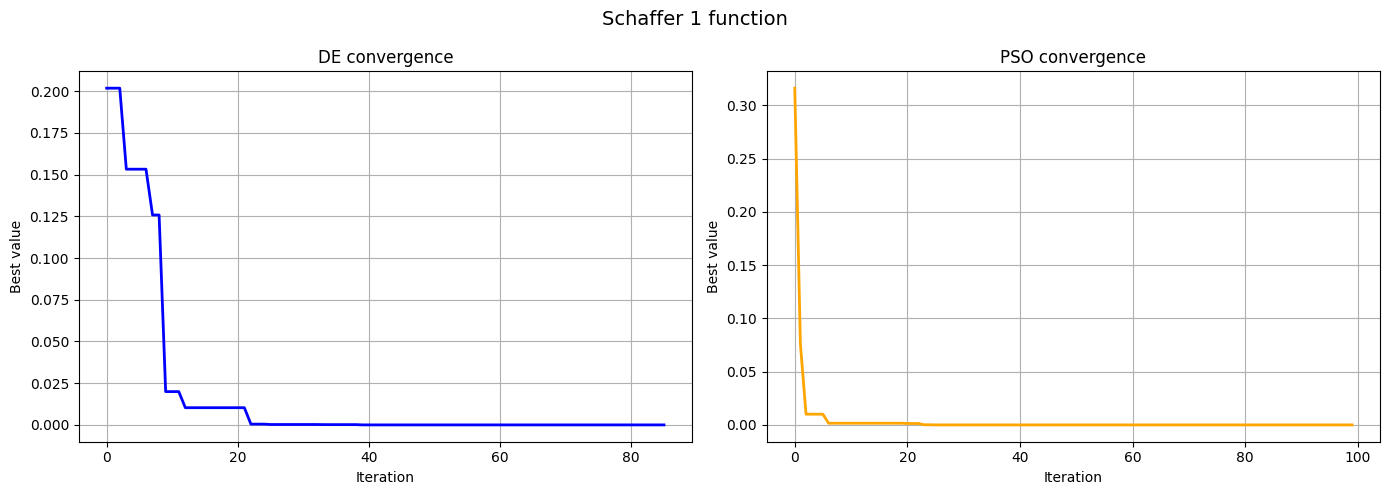

Ackley function

DE:
Best position: [0. 0.]
Best value: 0.0

PSO:
Best position: [ 2.e-06 -0.e+00]
Best value: 4e-06


2026-05-15 23:46:01,654 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.PillowWriter'>


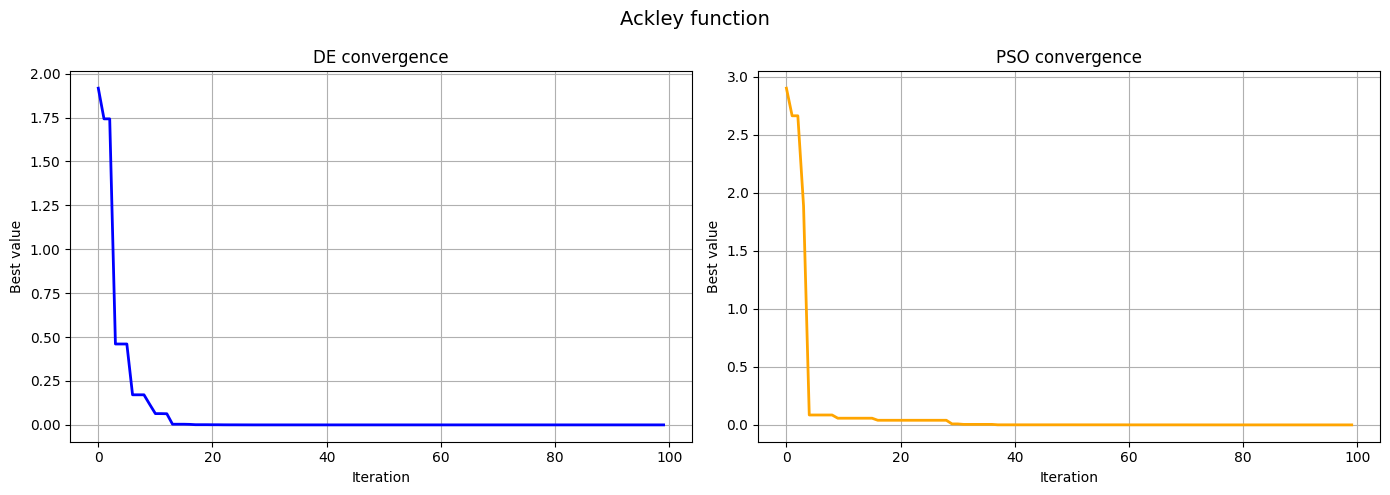

Holder function

DE:
Best position: [-8.055024  9.66459 ]
Best value: -19.208503

PSO:
Best position: [8.053708 9.689885]
Best value: -19.202018


2026-05-15 23:49:10,126 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.PillowWriter'>


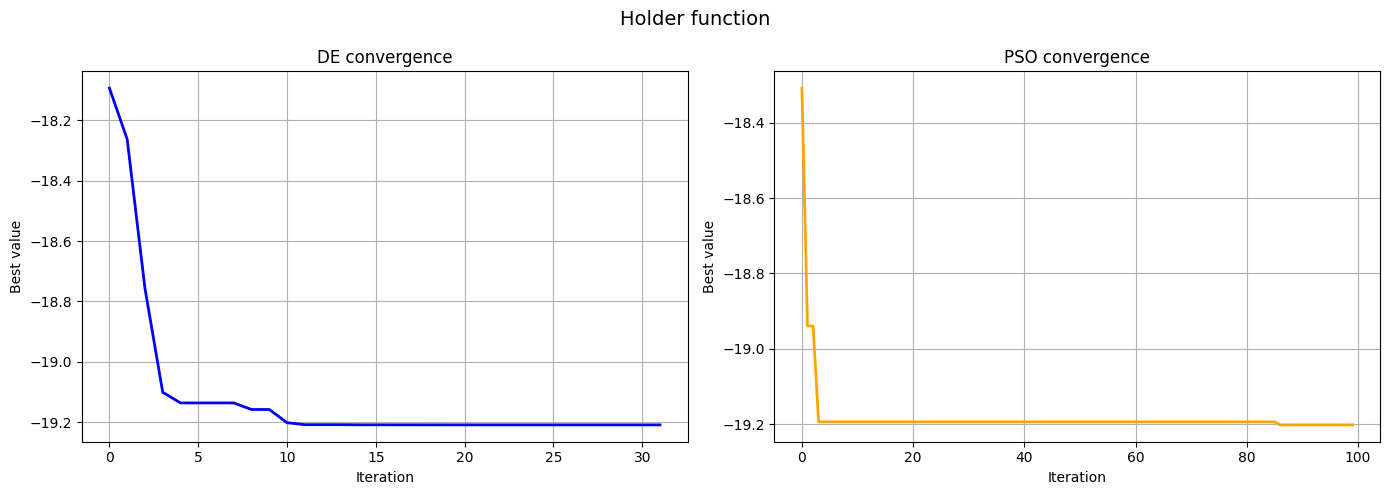

In [ ]:
results = []

for key, config in FUNCTIONS.items():

    print(config["name"])
    func = config["func"]
    bounds = config["bounds"]

    print("\nDE:")

    de_result, de_history = de(func, bounds)

    de_best_value = de_result.fun
    de_best_position = de_result.x

    print("Best position:", np.round(de_best_position, 6))
    print("Best value:", round(de_best_value, 6))

    print("\nPSO:")

    pso_best_value, pso_best_position, pso_history = pso(func, bounds)

    print("Best position:", np.round(pso_best_position, 6))
    print("Best value:", round(pso_best_value, 6))

    results.append({
        "Function": config["name"],

        "DE_best_x": de_best_position[0],
        "DE_best_y": de_best_position[1],
        "DE_best_value": de_best_value,

        "PSO_best_x": pso_best_position[0],
        "PSO_best_y": pso_best_position[1],
        "PSO_best_value": pso_best_value
    })

    create_gif(func=func, bounds=bounds, de_history=de_history, pso_history=pso_history, filename=f"{config['name']}.gif")

    plot(de_history, pso_history, title=config["name"] )

In [26]:
results_df = pd.DataFrame(results)
print(results_df.round(6))

              Function  DE_best_x  DE_best_y  DE_best_value  PSO_best_x  \
0  Schaffer 1 function   0.000000   -0.00000       0.000000    0.000003   
1      Ackley function   0.000000    0.00000       0.000000    0.000002   
2      Holder function  -8.055024    9.66459     -19.208503    8.053708   

   PSO_best_y  PSO_best_value  
0    0.000007        0.000000  
1   -0.000000        0.000004  
2    9.689885      -19.202018  
